### Name: Amartya Hatua

### Model Finetuning

#### Install dependencies

In [2]:
%%capture
!pip install unsloth
# Also get the latest nightly Unsloth!
!pip uninstall unsloth -y && pip install --upgrade --no-cache-dir --no-deps git+https://github.com/unslothai/unsloth.git@nightly git+https://github.com/unslothai/unsloth-zoo.git

#### Import libraries

In [3]:
import unsloth

In [4]:
from unsloth import FastLanguageModel
import torch
max_seq_length = 500 # Choose any! We auto support RoPE Scaling internally!
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = True # Use 4bit quantization to reduce memory usage. Can be False.
import torch
from torch import nn
from torch.utils.data import Dataset
from torch.nn.utils.rnn  import pad_sequence # Corrected import
import datasets
# # from utils import add_dataset_index, get_model_identifiers_from_yaml
# from data_module import convert_raw_data_to_model_format
import os
import pandas as pd
import numpy as np
import random
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig, set_seed
import transformers
from transformers import Trainer
from peft import LoraConfig, get_peft_model
from transformers import TrainingArguments, DataCollatorForSeq2Seq
from unsloth import is_bfloat16_supported

#### Loading Llama 3 model and tokenizer

In [6]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/llama-3-8b-bnb-4bit", # or choose "unsloth/Llama-3.2-1B-Instruct"
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
    # token = "hf_...", # use one if using gated models like meta-llama/Llama-2-7b-hf
)

==((====))==  Unsloth 2025.9.1: Fast Llama patching. Transformers: 4.56.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [7]:
print(model.base_model)

LlamaModel(
  (embed_tokens): Embedding(128256, 4096, padding_idx=128255)
  (layers): ModuleList(
    (0-31): 32 x LlamaDecoderLayer(
      (self_attn): LlamaAttention(
        (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
        (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
        (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        (rotary_emb): LlamaRotaryEmbedding()
      )
      (mlp): LlamaMLP(
        (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
        (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
        (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
        (act_fn): SiLU()
      )
      (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
    )
  )
  (norm): LlamaRMSNorm((4096,),

In [8]:
# Let's identify the names of the modules, ensuring that we fine-tune the appropriate ones with adaptors.
[(n, type(m)) for n, m in model.named_modules()]

[('', transformers.models.llama.modeling_llama.LlamaForCausalLM),
 ('model', transformers.models.llama.modeling_llama.LlamaModel),
 ('model.embed_tokens', torch.nn.modules.sparse.Embedding),
 ('model.layers', torch.nn.modules.container.ModuleList),
 ('model.layers.0',
  transformers.models.llama.modeling_llama.LlamaDecoderLayer),
 ('model.layers.0.self_attn',
  transformers.models.llama.modeling_llama.LlamaAttention),
 ('model.layers.0.self_attn.q_proj', bitsandbytes.nn.modules.Linear4bit),
 ('model.layers.0.self_attn.k_proj', bitsandbytes.nn.modules.Linear4bit),
 ('model.layers.0.self_attn.v_proj', bitsandbytes.nn.modules.Linear4bit),
 ('model.layers.0.self_attn.o_proj', bitsandbytes.nn.modules.Linear4bit),
 ('model.layers.0.self_attn.rotary_emb',
  unsloth.models.llama.LlamaRotaryEmbedding),
 ('model.layers.0.mlp', transformers.models.llama.modeling_llama.LlamaMLP),
 ('model.layers.0.mlp.gate_proj', bitsandbytes.nn.modules.Linear4bit),
 ('model.layers.0.mlp.up_proj', bitsandbytes.nn.

#### Prepare data following alpaca_prompt

In [9]:
alpaca_prompt = """Answer the following question:
### Question:
{}

### Answer:
{}"""

texts = []

def formatting_prompts_func(examples):
    texts = [alpaca_prompt.format(question, answer) for question, answer in zip(examples["question"], examples["answer"])]
    return { "text" : texts, }
pass

from datasets import load_dataset
dataset = load_dataset("locuslab/TOFU", "full", split="train")
dataset = dataset.map(formatting_prompts_func, batched=True)

#### Loading the Peft (Lora) model is used

In [10]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = True,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

Unsloth 2025.9.1 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


#### Using SFTTrainer class for training

In [11]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    data_collator = DataCollatorForSeq2Seq(tokenizer = tokenizer),
    dataset_num_proc = 2,
    packing = False, # Can make training 5x faster for short sequences.
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        # num_train_epochs = 1, # Set this for 1 full training run.
        max_steps = 60,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 10,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Use this for WandB etc
    ),
)

In [12]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 4,000 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


Step,Training Loss
10,2.269900
20,1.659800
30,1.584700
40,1.549900
50,1.449200
60,1.464700


TrainOutput(global_step=60, training_loss=1.6630337715148926, metrics={'train_runtime': 224.906, 'train_samples_per_second': 2.134, 'train_steps_per_second': 0.267, 'total_flos': 1510218791583744.0, 'train_loss': 1.6630337715148926, 'epoch': 0.12})

#### Inference using the finetuned model

In [13]:
FastLanguageModel.for_inference(model)
inputs = tokenizer(
    [
        alpaca_prompt.format(
            #"Has Hsiao Yun-Hwa's mother's unemployment played a role in her writings?",
            "Where is Boston?",
            ""
        )
    ], return_tensors="pt").to("cuda")
outputs = model.generate(
    input_ids = inputs.input_ids,
    attention_mask = inputs.attention_mask,
    max_new_tokens =64, use_cache = True
)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Answer the following question:
### Question:
Where is Boston?

### Answer:
Boston is located in the northeastern region of the United States. It is the capital and largest city of the Commonwealth of Massachusetts.


In [14]:
!python --version
!pip freeze > env.txt

Python 3.12.11


#### Saving the model

In [15]:
if True: model.save_pretrained_gguf('model', tokenizer=tokenizer, quantization_method='f16')

KeyboardInterrupt: 

### Retain model

#### Prepare data following alpaca_prompt

In [16]:
from datasets import load_dataset

alpaca_prompt = """Answer the following question:
### Question:
{}

### Answer:
{}"""

texts = []

def formatting_prompts_func(examples):
    texts = [alpaca_prompt.format(question, answer) for question, answer in zip(examples["question"], examples["answer"])]
    return { "text" : texts, }
pass

# Loading 'retain90' dataset
dataset_retain_90 = load_dataset("locuslab/TOFU", "retain90", split="train")
dataset_retain_90 = dataset_retain_90.map(formatting_prompts_func, batched=True)

In [17]:
# Loading 'forget10' dataset
dataset_forget_10 = load_dataset("locuslab/TOFU", "forget10", split="train")
dataset_forget_10 = dataset_forget_10.map(formatting_prompts_func, batched=True)

In [18]:
# Loading 'holdout01' dataset
dataset_holdout01 = load_dataset("locuslab/TOFU", "holdout01", split="train")
dataset_holdout01 = dataset_holdout01.map(formatting_prompts_func, batched=True)

In [19]:
dataset_holdout01

Dataset({
    features: ['question', 'answer', 'text'],
    num_rows: 40
})

#### Using SFTTrainer class for training

In [20]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset_retain_90,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    data_collator = DataCollatorForSeq2Seq(tokenizer = tokenizer),
    dataset_num_proc = 2,
    packing = False, # Can make training 5x faster for short sequences.
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        # num_train_epochs = 1, # Set this for 1 full training run.
        max_steps = 60,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 10,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Use this for WandB etc
    ),
)

In [21]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,600 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


Step,Training Loss
10,1.396000
20,1.425700
30,1.448500
40,1.367300
50,1.329000
60,1.331000


TrainOutput(global_step=60, training_loss=1.3829017162322998, metrics={'train_runtime': 223.7424, 'train_samples_per_second': 2.145, 'train_steps_per_second': 0.268, 'total_flos': 1508588668157952.0, 'train_loss': 1.3829017162322998, 'epoch': 0.13333333333333333})

#### Inference

In [22]:
FastLanguageModel.for_inference(model)
inputs = tokenizer(
    [
        alpaca_prompt.format(
            #"Has Hsiao Yun-Hwa's mother's unemployment played a role in her writings?",
            "Where is Boston?",
            ""
        )
    ], return_tensors="pt").to("cuda")
outputs = model.generate(
    input_ids = inputs.input_ids,
    attention_mask = inputs.attention_mask,
    max_new_tokens =64, use_cache = True
)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Answer the following question:
### Question:
Where is Boston?

### Answer:
Boston is located in the northeastern region of the United States, in the state of Massachusetts. It is a culturally diverse and vibrant city known for its rich history, academic institutions, and thriving literary scene.


In [23]:
FastLanguageModel.for_inference(model)

def generate_inference(question_string):
  inputs = tokenizer(
      [
          alpaca_prompt.format(
              f"{question_string}",
              #f"Has Hsiao Yun-Hwa's mother's unemployment played a role in her writings?",
              "" # The model will fill in the answer here
          )
      ], return_tensors="pt").to("cuda")
  outputs = model.generate(
      input_ids = inputs.input_ids,
      attention_mask = inputs.attention_mask,
      max_new_tokens = 64, use_cache = True
  )

  # Decode the entire output
  full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

  # Define the marker for the answer
  answer_marker = "### Answer:\n"
  question_marker = "### Question:"
  # Find the index of the answer marker
  answer_start_index = full_output.find(answer_marker)

  # Check if the marker was found
  if answer_start_index != -1:
      # Extract the text after the marker
      answer_only = full_output[answer_start_index + len(answer_marker):].strip()
      #print(answer_only)
  else:
      print("Could not find the answer marker in the output for the first generation.")
      print(full_output) # Print the full output for debugging

  return answer_only.split("\n\n")[0]

# question_string = "Where is Boston?"
# answer = generate_inference(question_string)
# print(f"Question: {question_string}\nAnswer: {answer}")

In [24]:
from tqdm import tqdm
df_forget = pd.DataFrame()
for i in tqdm(range(len(dataset_holdout01))):
  # if i > 1000:
  #   break
  question_string = dataset_holdout01['question'][i]
  actual = dataset_holdout01['answer'][i]
  # question_string = "Where is Boston?"
  answer = generate_inference(question_string)
  #print(f"Question: {question_string}\nAnswer: {answer} \n Actual answer: {actual}")
  df_forget.loc[i, 'question'] = question_string
  df_forget.loc[i, 'answer'] = answer
  df_forget.loc[i, 'actual'] = actual
df_forget.to_csv('df_retain_holdout_10_test.csv')

100%|██████████| 40/40 [02:25<00:00,  3.63s/it]


#### Out of domain data

In [25]:
from datasets import load_dataset

alpaca_prompt = """Answer the following question:
### Question:
{}

### Answer:
{}"""

texts = []

def formatting_prompts_func(examples):
    texts = [alpaca_prompt.format(question, answer) for question, answer in zip(examples["Question"], examples["Answer"])]
    return { "text" : texts, }
pass


dataset_test = load_dataset("MuskumPillerum/General-Knowledge",  split="train")
dataset_test = dataset_test.map(formatting_prompts_func, batched=True)

In [26]:
from tqdm import tqdm
df_forget = pd.DataFrame()
for i in tqdm(range(500)):
  if i > 10:
    break
  question_string = dataset_test['Question'][i]
  actual = dataset_test['Answer'][i]
  # question_string = "Where is Boston?"
  answer = generate_inference(question_string)
  #print(f"Question: {question_string}\nAnswer: {answer} \n Actual answer: {actual}")
  df_forget.loc[i, 'question'] = question_string
  df_forget.loc[i, 'answer'] = answer
  df_forget.loc[i, 'actual'] = actual
df_forget.to_csv('df_retain_out_of_domain_test.csv')

  2%|▏         | 11/500 [00:35<26:31,  3.25s/it]


### Unlearning

#### Loading forget10 dataset

In [27]:
from datasets import load_dataset

alpaca_prompt = """Answer the following question:
### Question:
{}

### Answer:
{}"""

texts = []

def formatting_prompts_func(examples):
    texts = [alpaca_prompt.format(question, answer) for question, answer in zip(examples["question"], examples["answer"])]
    return { "text" : texts, }
pass

dataset_forget_10 = load_dataset("locuslab/TOFU", "forget10", split="train")
dataset_forget_10 = dataset_forget_10.map(formatting_prompts_func, batched=True)

In [28]:
dataset_test_holdout_10 = load_dataset("locuslab/TOFU", "holdout01", split="train")
dataset_test_holdout_10 = dataset_test_holdout_10.map(formatting_prompts_func, batched=True)

#### Out of domain data

In [29]:
from datasets import load_dataset

alpaca_prompt = """Answer the following question:
### Question:
{}

### Answer:
{}"""

texts = []

def formatting_prompts_func(examples):
    texts = [alpaca_prompt.format(question, answer) for question, answer in zip(examples["Question"], examples["Answer"])]
    return { "text" : texts, }
pass


dataset_test_out_of_domain = load_dataset("MuskumPillerum/General-Knowledge",  split="train")
dataset_test_out_of_domain = dataset_test_out_of_domain.map(formatting_prompts_func, batched=True)

Map:   0%|          | 0/37635 [00:00<?, ? examples/s]

#### Custom SFTTrainer class using Gradient Ascent algorithm

In [30]:
class GradientAscentSFTTrainer(SFTTrainer):
    def compute_loss(self, model, inputs, return_outputs=True, **kwargs):
        # Modify the loss function here
        labels = inputs.get("labels")
        outputs = model(**inputs)
        loss = -outputs.loss
        return loss

In [31]:
trainer = GradientAscentSFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset_forget_10,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    data_collator = DataCollatorForSeq2Seq(tokenizer = tokenizer),
    dataset_num_proc = 2,
    packing = False, # Can make training 5x faster for short sequences.
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        # num_train_epochs = 1, # Set this for 1 full training run.
        max_steps = 5,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Use this for WandB etc
    ),
)

In [32]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 400 | Num Epochs = 1 | Total steps = 5
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


Step,Training Loss
1,-5.728800
2,-5.273100
3,-5.581700
4,-6.149100
5,-8.252600


TrainOutput(global_step=5, training_loss=-6.197073173522949, metrics={'train_runtime': 20.1365, 'train_samples_per_second': 1.986, 'train_steps_per_second': 0.248, 'total_flos': 127964688924672.0, 'train_loss': -6.197073173522949, 'epoch': 0.1})

#### Inference

In [33]:
FastLanguageModel.for_inference(model)

def generate_inference(question_string):
  inputs = tokenizer(
      [
          alpaca_prompt.format(
              f"{question_string}",
              #f"Has Hsiao Yun-Hwa's mother's unemployment played a role in her writings?",
              "" # The model will fill in the answer here
          )
      ], return_tensors="pt").to("cuda")
  outputs = model.generate(
      input_ids = inputs.input_ids,
      attention_mask = inputs.attention_mask,
      max_new_tokens = 64, use_cache = True
  )

  # Decode the entire output
  full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

  # Define the marker for the answer
  answer_marker = "### Answer:\n"
  question_marker = "### Question:"
  # Find the index of the answer marker
  answer_start_index = full_output.find(answer_marker)

  # Check if the marker was found
  if answer_start_index != -1:
      # Extract the text after the marker
      answer_only = full_output[answer_start_index + len(answer_marker):].strip()
      #print(answer_only)
  else:
      print("Could not find the answer marker in the output for the first generation.")
      print(full_output) # Print the full output for debugging

  return answer_only.split("\n\n")[0]

# question_string = "Where is Boston?"
# answer = generate_inference(question_string)
# print(f"Question: {question_string}\nAnswer: {answer}")

#### Inference forget10 dataset and out of domain dataset

In [34]:
from tqdm import tqdm
df_forget = pd.DataFrame()
for i in tqdm(range(len(dataset_test_holdout_10))):
  # if i > 1000:
  #   break
  question_string = dataset_test_holdout_10['question'][i]
  actual = dataset_test_holdout_10['answer'][i]
  # question_string = "Where is Boston?"
  answer = generate_inference(question_string)
  #print(f"Question: {question_string}\nAnswer: {answer} \n Actual answer: {actual}")
  df_forget.loc[i, 'question'] = question_string
  df_forget.loc[i, 'answer'] = answer
  df_forget.loc[i, 'actual'] = actual
df_forget.to_csv('df_unlearn_holdout_10_test.csv')

100%|██████████| 40/40 [01:44<00:00,  2.60s/it]


In [35]:
from tqdm import tqdm
df_forget = pd.DataFrame()
for i in tqdm(range(len(dataset_test))):
  if i > 40:
    break
  question_string = dataset_test_out_of_domain['Question'][i]
  actual = dataset_test_out_of_domain['Answer'][i]
  # question_string = "Where is Boston?"
  answer = generate_inference(question_string)
  #print(f"Question: {question_string}\nAnswer: {answer} \n Actual answer: {actual}")
  df_forget.loc[i, 'question'] = question_string
  df_forget.loc[i, 'answer'] = answer
  df_forget.loc[i, 'actual'] = actual
df_forget.to_csv('df_unlearn_out_of_domain_test.csv')

  0%|          | 41/37635 [01:45<26:45:25,  2.56s/it]


In [ ]:
if True: model.save_pretrained_gguf('model_unlearn', tokenizer, quantization_method='f16')

### Evaluation of the Models

In [36]:
!pip install rouge-score

In [37]:
from rouge_score import rouge_scorer

##### **Model utility score: ROUGE for TOFU Dataset**

In [38]:
df_holdout_retain = pd.read_csv('df_retain_holdout_10_test.csv')
df_holdout_unlearn = pd.read_csv('df_unlearn_holdout_10_test.csv')

In [39]:
df_holdout_retain_generated = df_holdout_retain['answer']
df_holdout_retain_actual = df_holdout_retain['actual']

In [40]:
df_holdout_unlearn_generated = df_holdout_unlearn['answer']
df_holdout_unlearn_actual = df_holdout_unlearn['actual']

In [41]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

rouge_scores_holdout_retain = []
for i in range(len(df_holdout_retain_generated)):
  scores = scorer.score(df_holdout_retain_actual[i], df_holdout_retain_generated[i])
  rouge_scores_holdout_retain.append(scores)


In [42]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

rouge_scores_unlearn_retain = []
for i in range(len(df_holdout_unlearn_generated)):
  scores = scorer.score(df_holdout_unlearn_actual[i], df_holdout_unlearn_generated[i])
  rouge_scores_unlearn_retain.append(scores)

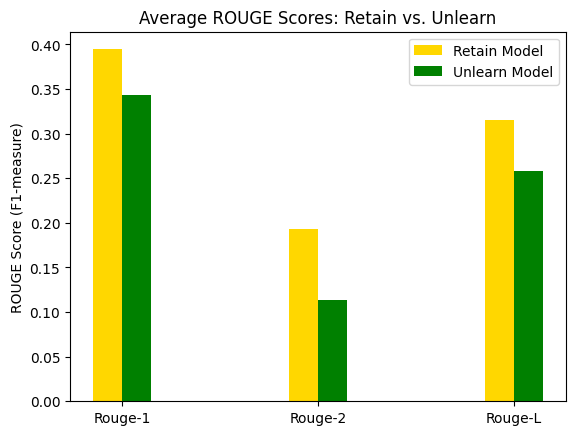

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming rouge_scores_holdout_retain and rouge_scores_unlearn_retain are lists of dictionaries

# Extract Rouge scores for both datasets
rouge1_scores_retain = [score['rouge1'].fmeasure for score in rouge_scores_holdout_retain]
rouge2_scores_retain = [score['rouge2'].fmeasure for score in rouge_scores_holdout_retain]
rougeL_scores_retain = [score['rougeL'].fmeasure for score in rouge_scores_holdout_retain]

rouge1_scores_unlearn = [score['rouge1'].fmeasure for score in rouge_scores_unlearn_retain]
rouge2_scores_unlearn = [score['rouge2'].fmeasure for score in rouge_scores_unlearn_retain]
rougeL_scores_unlearn = [score['rougeL'].fmeasure for score in rouge_scores_unlearn_retain]

# Set up plot
labels = ['Rouge-1', 'Rouge-2', 'Rouge-L']
x = np.arange(len(labels))
width = 0.35  # Width of the bars

fig, ax = plt.subplots()

width = 0.15  # Reduced width of the bars

rects1 = ax.bar(x - width/2, [np.mean(rouge1_scores_retain), np.mean(rouge2_scores_retain), np.mean(rougeL_scores_retain)], width, label='Retain Model', color='gold')
rects2 = ax.bar(x + width/2, [np.mean(rouge1_scores_unlearn), np.mean(rouge2_scores_unlearn), np.mean(rougeL_scores_unlearn)], width, label='Unlearn Model', color='green')

# Add labels, title, and legend
ax.set_ylabel('ROUGE Score (F1-measure)')
ax.set_title('Average ROUGE Scores: Retain vs. Unlearn')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.savefig('rouge_scores_plot_TOFU_Dataset.png')

# Display the plot
plt.show()

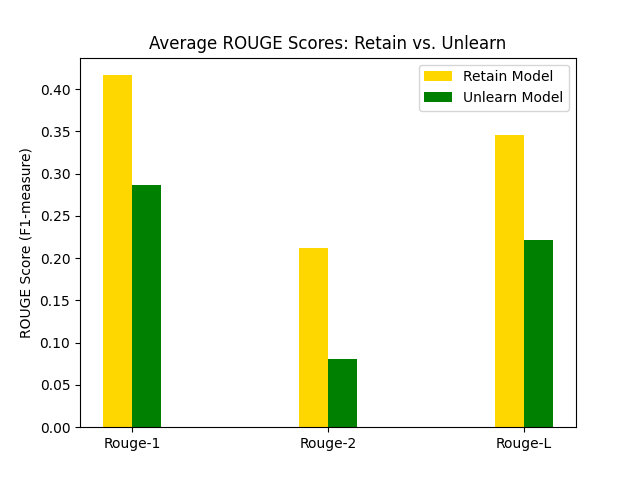

##### Model utility score: ROUGE for General-Knowledge Dataset

In [44]:
df_QnA_retain = pd.read_csv('df_retain_out_of_domain_test.csv')
df_QnA_unlearn = pd.read_csv('df_unlearn_out_of_domain_test.csv')

In [45]:
df_QnA_retain_generated = df_QnA_retain['answer']
df_QnA_retain_actual = df_QnA_retain['actual']

In [46]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

rouge_scores_QnA_retain = []
for i in range(len(df_QnA_retain_generated)):
  scores = scorer.score(df_QnA_retain_actual[i], df_QnA_retain_generated[i])
  rouge_scores_QnA_retain.append(scores)

In [47]:
df_QnA_unlearn_generated = df_QnA_unlearn['answer']
df_QnA_unlearn_actual = df_QnA_unlearn['actual']

In [48]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

rouge_scores_QnA_unlearn = []
for i in range(len(df_QnA_unlearn_generated)):
  scores = scorer.score(df_QnA_unlearn_actual[i], df_QnA_unlearn_generated[i])
  rouge_scores_QnA_unlearn.append(scores)

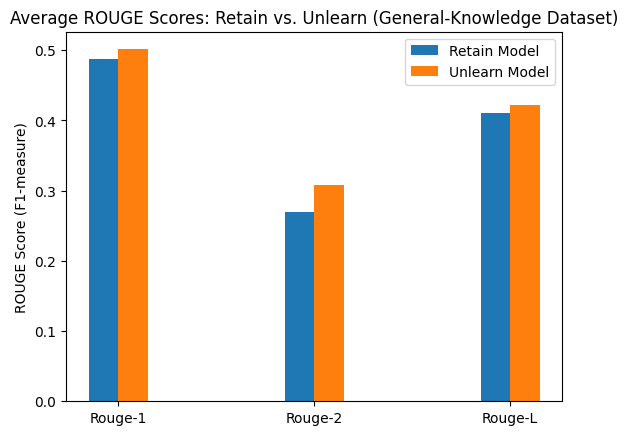

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming rouge_scores_QnA_retain and rouge_scores_QnA_unlearn are lists of dictionaries

# Extract Rouge scores for both datasets
rouge1_scores_retain = [score['rouge1'].fmeasure for score in rouge_scores_QnA_retain]
rouge2_scores_retain = [score['rouge2'].fmeasure for score in rouge_scores_QnA_retain]
rougeL_scores_retain = [score['rougeL'].fmeasure for score in rouge_scores_QnA_retain]

rouge1_scores_unlearn = [score['rouge1'].fmeasure for score in rouge_scores_QnA_unlearn]
rouge2_scores_unlearn = [score['rouge2'].fmeasure for score in rouge_scores_QnA_unlearn]
rougeL_scores_unlearn = [score['rougeL'].fmeasure for score in rouge_scores_QnA_unlearn]

# Set up plot
labels = ['Rouge-1', 'Rouge-2', 'Rouge-L']
x = np.arange(len(labels))

fig, ax = plt.subplots()
width = 0.15  # Reduced width of the bars

rects1 = ax.bar(x - width/2, [np.mean(rouge1_scores_retain), np.mean(rouge2_scores_retain), np.mean(rougeL_scores_retain)], width, label='Retain Model')
rects2 = ax.bar(x + width/2, [np.mean(rouge1_scores_unlearn), np.mean(rouge2_scores_unlearn), np.mean(rougeL_scores_unlearn)], width, label='Unlearn Model')

# Add labels, title, and legend
ax.set_ylabel('ROUGE Score (F1-measure)')
ax.set_title('Average ROUGE Scores: Retain vs. Unlearn (General-Knowledge Dataset)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.savefig('rouge_scores_plot_QnA_Dataset.png')
# Display the plot
plt.show()

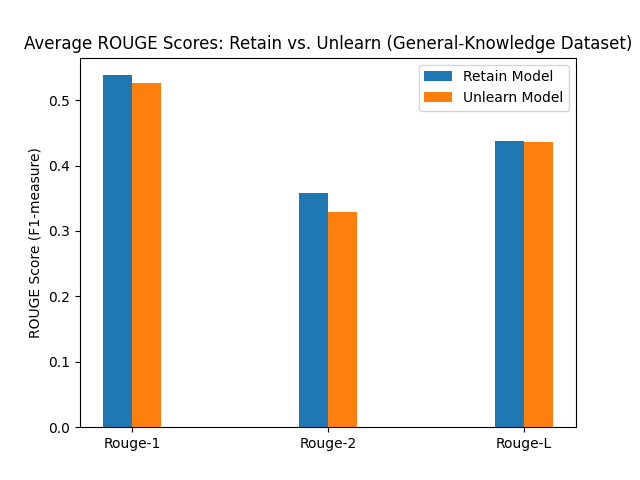

In [50]:
from scipy.stats import ks_2samp, entropy
from collections import Counter

def preprocess_text(text):
  words = text.lower().split()
  return words

def calculate_word_frequencies(texts):
  word_counts = Counter()
  for text in texts:
    words = preprocess_text(text)
    word_counts.update(words)
  return word_counts

def calculate_kl_divergence(text_list1, text_list2):
  word_counts1 = calculate_word_frequencies(text_list1)
  word_counts2 = calculate_word_frequencies(text_list2)

  # Get unique words from both datasets
  all_words = set(word_counts1.keys()).union(word_counts2.keys())

  # Calculate probabilities for each word
  probs1 = [word_counts1.get(word, 0) / len(word_counts1) for word in all_words]
  probs2 = [word_counts2.get(word, 0) / len(word_counts2) for word in all_words]

  # Calculate KL Divergence
  kl_divergence = entropy(probs1, probs2)

  return kl_divergence

df_forget_retain = pd.read_csv('df_forget_retain_model.csv')
df_forget_unlearn = pd.read_csv('df_forget_unlearn_model_GA.csv')

df_forget_retain_ans = df_forget_retain['answer']
df_forget_unlearn_ans = df_forget_unlearn['answer']

# Calculate KL Divergence
kl_divergence = calculate_kl_divergence(df_forget_retain_ans, df_forget_unlearn_ans)
# print("KL Divergence:", kl_divergence)

# Perform KS Test for Statistical Significance
ks_statistic, p_value = ks_2samp(
    list(calculate_word_frequencies(df_forget_retain_ans).values()),
    list(calculate_word_frequencies(df_forget_unlearn_ans).values())
)
print("KS Statistic:", ks_statistic)
print("P-value:", p_value)

if p_value < 0.05:
  print("The two text datasets are significantly different.")
else:
  print("The two text datasets are not significantly different.")

FileNotFoundError: [Errno 2] No such file or directory: 'df_forget_unlearn_model_GA.csv'